# Pratica: loss function, MSE e cost function - dataset lineare

Nel notebook precedente abbiamo introdotto il concetto di errore, loss function e cost function.

In questo notebook riprendiamo gli stessi concetti, ma li calcoliamo passo dopo passo usando NumPy. Useremo una versione del dataset `metrorates` costruita in modo che i punti siano sparsi attorno a una retta. L'obiettivo e fare i conti a mano, senza usare modelli gia pronti.

## Obiettivi

In questa pratica dovrai:

1. caricare il dataset `metrorates`;
2. costruire previsioni con una retta `f_wb(x)`;
3. calcolare gli errori tra previsioni e valori reali;
4. calcolare la loss su singoli esempi;
5. calcolare MSE e cost function usando NumPy;
6. confrontare piu rette e scegliere quella con costo piu basso.

Il dataset contiene il prezzo al metro quadro di alcune case in funzione della distanza dalla metro. In questa versione i punti seguono una tendenza approssimativamente lineare decrescente.

## 1. Importare librerie e dati

Partiamo dal nuovo dataset. La variabile `x` contiene la distanza dalla metro in metri, mentre `y` contiene il prezzo della casa al metro quadro.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('metrorates.csv')

df.head()

# stampa le prime righe del dataset

,Distanza_Metro_Metri,Prezzo_Casa_MQ
0,50,4460
1,80,4335
2,120,4380
3,180,4215
4,250,4140


## 2. Descrivere il dataset con pandas

Prima di calcolare errori e costi, osserviamo le statistiche principali del dataset usando pandas.

In [2]:
# descrivi il dataset con pandas
df.describe()

,Distanza_Metro_Metri,Prezzo_Casa_MQ
count,20.000000,20.00000
mean,1083.500000,3409.50000
std,952.891859,864.53197
min,50.000000,1665.00000
25%,302.500000,2886.25000
50%,785.000000,3632.50000
75%,1675.000000,4106.25000
max,3000.000000,4460.00000


## 3. Creare gli array NumPy e visualizzare i dati

Ora assegniamo le colonne del dataset agli array NumPy `x` e `y`, poi visualizziamo la relazione tra distanza dalla metro e prezzo al metro quadro.

In [3]:
x = df['Distanza_Metro_Metri'].values
y = df['Prezzo_Casa_MQ'].values

print('Numero di esempi:', len(x))
print('Prime distanze:', x[:5])
print('Primi prezzi:', y[:5])
print('Forma di x:', x.shape)
print('Forma di y:', y.shape)

Numero di esempi: 20
Prime distanze: [ 50  80 120 180 250]
Primi prezzi: [4460 4335 4380 4215 4140]
Forma di x: (20,)
Forma di y: (20,)


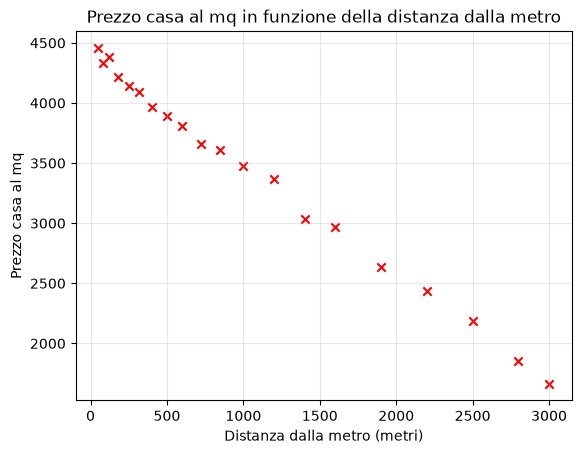

In [4]:
plt.scatter(x, y, color='red', marker='x')
plt.title('Prezzo casa al mq in funzione della distanza dalla metro')
plt.xlabel('Distanza dalla metro (metri)')
plt.ylabel('Prezzo casa al mq')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Scrivere il modello lineare

Usiamo ancora una retta:

$$f_{w,b}(x) = wx + b$$

In questo dataset ci aspettiamo un valore di `w` negativo: quando la distanza dalla metro aumenta, il prezzo tende a scendere.

In [5]:
def f_wb(x, w, b):
    return w * x + b

w = -1.0 # prendiamo dei valori iniziali arbitrari
b = 4500 # prendiamo dei valori iniziali arbitrari

previsioni = f_wb(x, w, b)

# controlla che tu abbia tante previsioni quanti data points

## 5. Calcolare l'errore a mano per un singolo data point

Abbiamo gia calcolato il vettore delle previsioni nella cella precedente. Ora prendiamo un solo data point e calcoliamo a mano il suo errore, cosi ripassiamo la formula.

Usiamo il primo punto del dataset:

$$errore = previsione - valore\ reale$$

La loss quadratica e semplicemente l'errore al quadrato:

$$loss = errore^2$$

In [6]:
indice = 0 # calcoliamo le seguenti metriche per il primo esempio del dataset.

x_i = x[indice]
y_i = y[indice]
previsione_i = previsioni[indice]

# implementa l'errore usando la formula nella cella sopra
errore_i = previsione_i - y_i

# implementa la loss usando la formula nella cella sopra
loss_i = errore_i ** 2

print(f'Distanza dalla metro: {x_i:.0f} metri')
print(f'Prezzo reale:         {y_i:.0f}')
print(f'Previsione:           {previsione_i:.0f}')
print(f'Errore:               {errore_i:.0f}')
print(f'Loss:                 {loss_i:.0f}')

Distanza dalla metro: 50 metri
Prezzo reale:         4460
Previsione:           4450
Errore:               -10
Loss:                 100


## 6. Definire la funzione di loss

Ora trasformiamo i due passaggi precedenti in una funzione. La funzione prende i valori reali, cioe `valori_reali`, e i valori prodotti dal modello, cioe `previsioni`.

Dentro la funzione dobbiamo calcolare prima la differenza e poi elevarla al quadrato:

$$loss = (previsioni - valori\ reali)^2$$

La stessa funzione potra poi essere applicata sia a un singolo esempio sia a tutti gli esempi del dataset.

In [7]:
def calculate_losses(valori_reali, previsioni):
    losses = (previsioni - valori_reali) ** 2 # calcola e ritorna l'array delle losses
    return losses

losses = calculate_losses(y, previsioni)

confronto = pd.DataFrame({
    'distanza_metro': x,
    'prezzo_reale': y,
    'previsione': previsioni,
    'loss': losses
})

confronto.head()

,distanza_metro,prezzo_reale,previsione,loss
0,50,4460,4450.0,100.0
1,80,4335,4420.0,7225.0
2,120,4380,4380.0,0.0
3,180,4215,4320.0,11025.0
4,250,4140,4250.0,12100.0


## 7. Calcolare il MSE con NumPy

Il **Mean Squared Error (MSE)** e la media delle loss su tutti gli esempi:

$$MSE = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Calcoliamolo in modo esplicito, un passaggio alla volta.

In [14]:
m = len(x) # quanti esempi ci sono nel nostro dataset?
somma_loss = np.sum(losses) # facciamo la sommatoria delle losses calcolate precedentemente
mse = somma_loss / m # troviamo il valore medio delle losses

print(f'Numero di esempi: {m}')
print(f'Somma delle loss: {somma_loss:.2f}')
print(f'MSE:              {mse:.2f}')

Numero di esempi: 20
Somma delle loss: 211100.00
MSE:              10555.00


## 8. Dall'MSE alla Half MSE

Nel notebook precedente abbiamo visto che nel ML si usa spesso questa cost function piuttosto che direttamente la MSE:

$$J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Questa e meta del MSE. Il fattore $\frac{1}{2}$ non cambia quale retta e migliore: rende solo piu comoda la derivata quando useremo il gradient descent.

Ora trasformiamo i passaggi precedenti in due funzioni:

- `compute_mse`: calcola il Mean Squared Error;
- `compute_cost`: calcola $J(w,b)$, cioe meta del MSE.

In [ ]:
def compute_mse(x, y, w, b):
    previsioni = None # Usa il modello lineare per calcolare le previsioni su tutto il dataset
    errori = None # Calcola gli errori per tutte le previsioni fatte
    losses = None # Calcola le losses per tutti gli errori
    mse = None # Calcola il Mean Squared Error con NumPy partendo dalle precedenti losses
    return mse

def compute_cost(x, y, w, b):
    # utilizza la funzione definita precedentemente, chiamandola con i corretti parametri
    # e ritorna il costo totale
    return None
    

print(f'MSE:   {compute_mse(x, y, w, b):.2f}')
print(f'Costo: {compute_cost(x, y, w, b):.2f}')

## 10. Confrontare piu rette

Ora proviamo piu coppie `(w, b)`. Ricorda: in questo dataset `w` dovrebbe essere negativo, perche il prezzo tende a diminuire quando la distanza dalla metro aumenta.

Modifica la lista `tentativi` aggiungendo altre coppie e prova ad abbassare il costo.

In [ ]:
tentativi = [
    (-0.70, 4000),
    (-0.95, 4450),
    (-1.20, 4700),
    # aggiungi qui altri tentativi
]

risultati = []

plt.scatter(x, y, color='red', marker='x', label='Dati reali')

for w_tentativo, b_tentativo in tentativi:
    costo_tentativo = compute_cost(x, y, w_tentativo, b_tentativo)
    mse_tentativo = compute_mse(x, y, w_tentativo, b_tentativo)
    risultati.append((w_tentativo, b_tentativo, mse_tentativo, costo_tentativo))
    plt.plot(x, f_wb(x, w_tentativo, b_tentativo), label=f'w={w_tentativo}, b={b_tentativo}')

plt.title('Confronto tra rette')
plt.xlabel('Distanza dalla metro (metri)')
plt.ylabel('Prezzo casa al mq')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame(risultati, columns=['w', 'b', 'MSE', 'costo']).sort_values('costo')

## 11. Esercizio: trova parametri migliori

Prova a trovare una coppia `(w, b)` con costo piu basso rispetto ai tentativi precedenti.

Range consigliati:

- `w` tra `-1.2` e `-0.7`;
- `b` tra `4000` e `4700`.

Suggerimento: cambia un parametro alla volta. Prima prova a fissare `b` e variare `w`, poi fai il contrario.

In [ ]:
# Modifica questi valori e rilancia la cella
w_prova = -0.95
b_prova = 4450

mse_prova = compute_mse(x, y, w_prova, b_prova)
costo_prova = compute_cost(x, y, w_prova, b_prova)

print(f'w={w_prova}, b={b_prova}')
print(f'MSE:   {mse_prova:.2f}')
print(f'Costo: {costo_prova:.2f}')

plt.scatter(x, y, color='red', marker='x', label='Dati reali')
plt.plot(x, f_wb(x, w_prova, b_prova), label='Retta scelta')
plt.title('La tua retta')
plt.xlabel('Distanza dalla metro (metri)')
plt.ylabel('Prezzo casa al mq')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Guardare come cambia il costo

Fissiamo `b` e facciamo variare solo `w`. In questo modo possiamo vedere come cambia il costo quando la retta diventa piu o meno inclinata.

In [ ]:
b_fisso = 4450
valori_w = np.arange(-1.25, -0.64, 0.05)
costi = [compute_cost(x, y, w_corrente, b_fisso) for w_corrente in valori_w]

plt.plot(valori_w, costi, marker='o')
plt.title('Costo al variare di w')
plt.xlabel('w')
plt.ylabel('Costo J(w, b)')
plt.grid(True, alpha=0.3)
plt.show()

indice_migliore = np.argmin(costi)
print(f'Miglior w tra quelli provati: {valori_w[indice_migliore]:.2f}')
print(f'Costo minimo nel grafico: {costi[indice_migliore]:.2f}')

## 13. Mini sfida finale

Rispondi modificando le celle precedenti:

1. Quale coppia `(w, b)` hai trovato con il costo piu basso?
2. Il costo e l'MSE danno lo stesso ordinamento delle rette?
3. Perche in questo dataset ha senso provare valori negativi di `w`?
4. Cosa succede se scegli `w` positivo?

## Riepilogo

In questo notebook hai praticato i concetti del 2a:

- il modello lineare produce previsioni con `w * x + b`;
- l'errore confronta previsione e valore reale;
- la loss quadratica misura l'errore su un singolo esempio;
- il MSE e la media delle loss su tutto il dataset;
- la cost function $J(w,b)$ usata qui e meta del MSE;
- confrontare i costi permette di scegliere parametri migliori in modo piu preciso rispetto al solo grafico;
- in questa versione del dataset i punti sono distribuiti attorno a una tendenza quasi lineare, quindi il modello lineare e una scelta didatticamente coerente.

Nelle lezioni precedenti valutavamo in maniera puramente visiva quali fossero i parametri `w` e `b` piu appropriati per permettere al modello lineare di rappresentare al meglio i nostri dati. Ora possiamo usare una metrica numerica, cioe la funzione di costo. Rimane comunque il problema di dover scegliere manualmente i valori di `w` e `b`: sarebbe utile avere un processo per sceglierli in maniera automatica e ottimale.